# Laboratorul 7

Rezolvați exercițiile de mai jos în celulele care v-au fost puse la dispoziție. La final, rulați tot notebook-ul și asigurați-vă că nu aveți erori. Salvați fișierul și încărcați-l în assignment-ul de Teams corespunzător grupei voastre.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Exercițiul 1

Realizați graficele din figurile 1 și 2 din îndrumar pentru un semnal sinusoidal cu o frecvență aleasă de voi, _alta_ decât cea utilizată aici.

Reamintim că graficul din dreapta din figura 1 reprezintă înfășurarea semnalului pe cercul unitate, anume reprezentarea în planul complex a șirului $y[n] = x[n] \cdot e^{-2 \pi i n}$.

De asemenea, figura 2 arată influența diferitelor frecvențe de înfășurare asupra formei pe care o are această reprezentare. \
Afișați grafic $z_{\omega} [n] = x[n] \cdot e^{-2 \pi i \omega n}$, pentru **patru valori diferite** ale $\omega$, dintre care una egală cu frecvența semnalului.

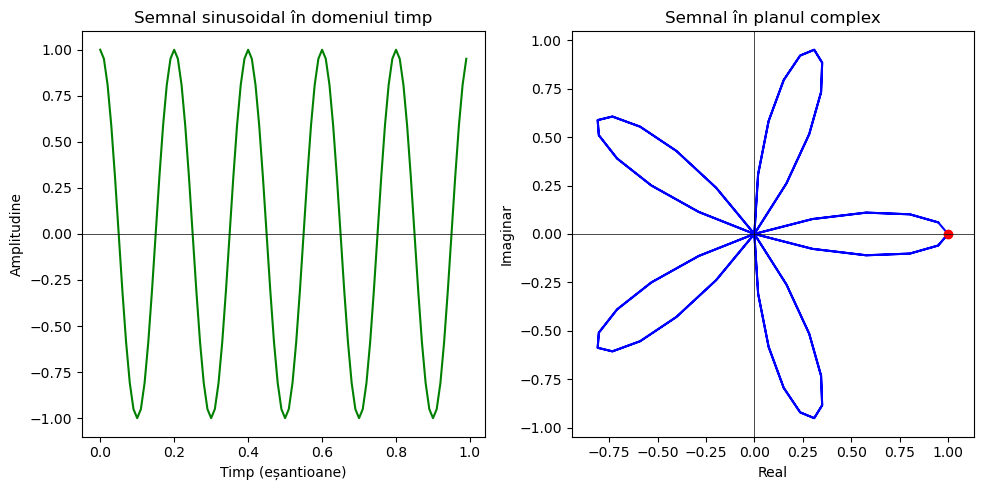

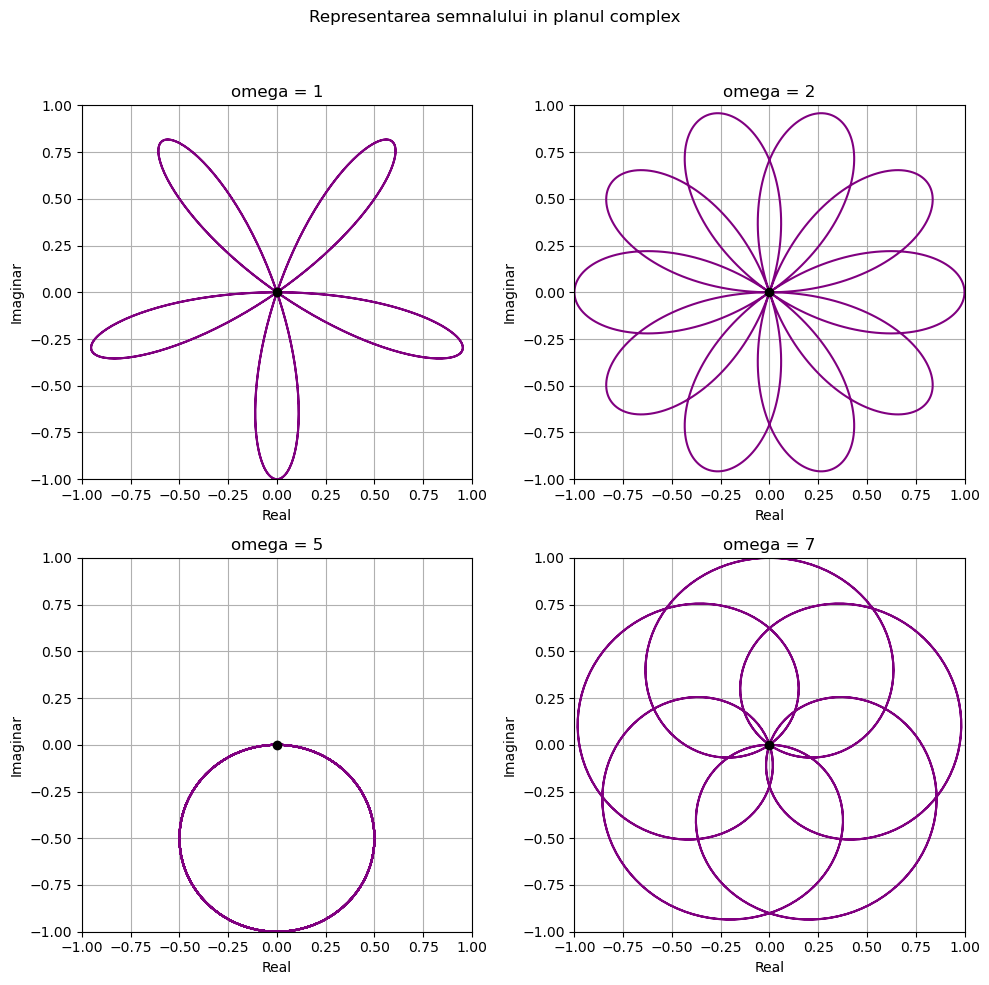

In [36]:
import numpy as np
import matplotlib.pyplot as plt

fs = 100
T = 1
n = np.arange(0, T, 1/fs)

f_signal = 5

x_n = np.sin(2 * np.pi * f_signal * n + np.pi / 2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(n, x_n, color='green')
plt.axhline(0, color='black', linewidth=0.5)
plt.title("Semnal sinusoidal în domeniul timp")
plt.xlabel("Timp (eșantioane)")
plt.ylabel("Amplitudine")

y_n = x_n * np.exp(-2j * np.pi * n)
plt.subplot(1, 2, 2)
plt.plot(y_n.real, y_n.imag, color='blue')
plt.plot(y_n.real[50], y_n.imag[50], 'ro')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Semnal în planul complex")
plt.xlabel("Real")
plt.ylabel("Imaginar")
plt.axis('equal')

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, figsize=(10, 10))
for idx, omega in enumerate(omega_values):
    z = x * np.exp(-2j * math.pi * omega * t / samples)
    ax = axs[idx // 2, idx % 2]
    ax.plot(np.real(z), np.imag(z), color='purple')
    ax.plot(0, 0, 'ko')
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginar')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_title(f'omega = {omega}')
    ax.grid(True)
plt.suptitle("Representarea semnalului in planul complex")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Exercițiul 2

Afișați **modulul** (valoarea absolută) a transformatei Fourier (folosind relația 1 din PDF) pentru un semnal compus de voi, având **cel puțin trei componente de frecvență distincte** (obțineți un grafic asemănător figurii 3).

Ajustați frecvențele de înfășurare $\omega$ utilizate în transformata Fourier în funcție de frecvența caracteristică a sinusoidei.

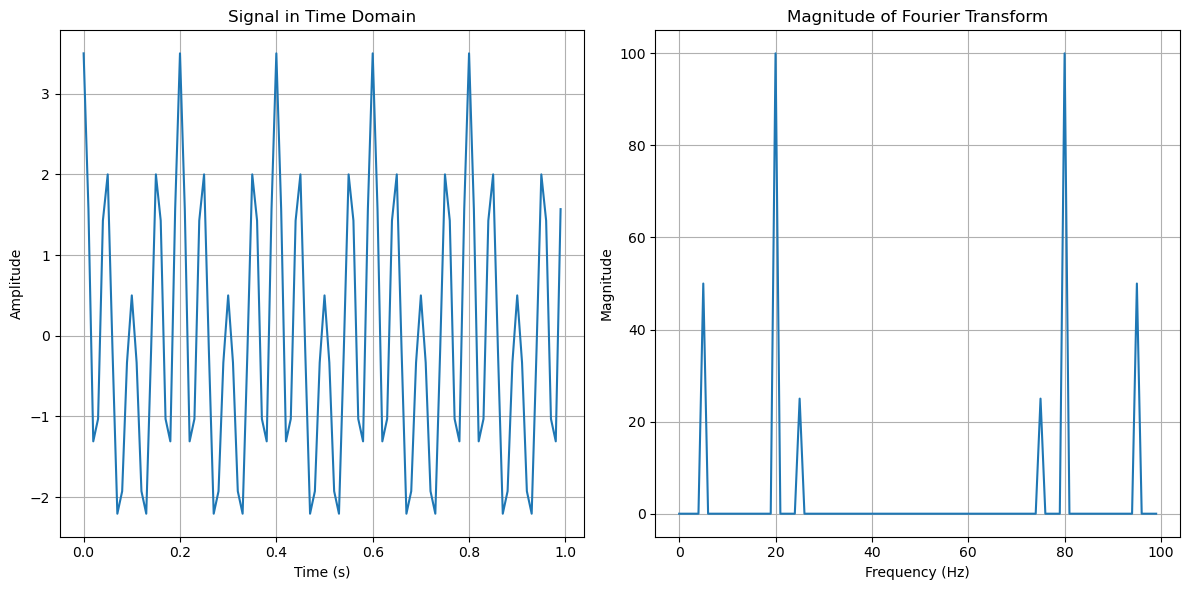

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import cmath 

sampling_rate = 100
time_step = 1 / sampling_rate
num_samples = 100
time_vector = np.arange(0, num_samples) * time_step

frequency1 = 5
frequency2 = 20
frequency3 = 75

signal = [math.cos(2 * math.pi * frequency1 * t) + 2 * math.cos(2 * math.pi * frequency2 * t) + 0.5 * math.cos(2 * math.pi * frequency3 * t) for t in time_vector]

def compute_fourier_transform(signal, num_samples):
    transform_result = []
    for freq in range(num_samples):
        transform_result.append(sum(signal[n] * cmath.exp(-2j * math.pi * freq * n / num_samples) for n in range(num_samples)))
    return transform_result

fourier_result = compute_fourier_transform(signal, num_samples)

magnitude_spectrum = [math.sqrt(val.real**2 + val.imag**2) for val in fourier_result]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(time_vector, signal)
plt.title("Signal in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)

frequency_vector = np.arange(num_samples) * sampling_rate / num_samples
plt.subplot(1, 2, 2)
plt.plot(frequency_vector, magnitude_spectrum)
plt.title("Magnitude of Fourier Transform")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.tight_layout()
plt.show()
